# Emerging Technologies

In [1]:
import numpy as np
import random
import qiskit
from qiskit import QuantumCircuit
from qiskit_aer import Aer
import matplotlib.pyplot as plt


## Introduction

## Problem 1: Generating Random Boolean Functions
**Deutsch's** algorithm is used along with another quantum algorithm to achieve faster computation. It is used to determine if a function is either balanced or constant, needing only one query. The amount of either $\textit{0}$ or $\textit{1}$ bits outputted determines whether its balanced or constant.

**Deutsch-Jozsa** algorithm came about when Deutsch and Jozsa worked further on the algorithm, that was initially created by Deutsch, into more qubits (quantum bits). This allowed for more computational power for quantum computers. It works similarly to *Deutsch's* algorithm, determining whether a function is balanced or constant. However, this algorithm goes from $\textit{n}$ bits to $\textit{1}$:
- Balanced = $\textit{0}$, $\textit{1}$ outputs equal amount of times
- Constant = Always outputs $\textit{0}$ or $\textit{1}$

### Helper Function
This function is used in the `random_constant_balanced` function to convert an arbitrary number of binary arguments into a single integer value. 

The process goes as follows:

1. **Allow an arbitrary number of binary arguments.**
    - `*args` allows any amount arguments.
    - Arguments can be $\textit{0}$ or $\textit{1}$, or $\textit{True}$ or $\textit{False}$.

2. **Change each argument into a binary character.**
    - For each $\textit{i}$:
        - If argument is $\textit{1}$ or $\textit{True}$:
            - Converts to `'1'`.
        - If argument is $\textit{0}$ or $\textit{False}$:
            - Converts to `'0'`.

3. **Concatenate into binary string.**
    - `join()` combines all characters into a single string.
    - `(1, 0, 1, 1)` = `'1011'`.

4. **Convert binary string into integer.**
    - `int(..., 2)`
    - Reads the string as a binary number.
        - `2` indicates the values are already binary.
    - Converts into its decimal value.
    - `'1011'` = `11`.

In [ ]:
def bin_args_to_int(*args):
    """Change an arbitrary number of binary arguments to an integer value.

    Accepts 0 and 1, and True or False values:
        Returns corresponding integer
    """
    return int(''.join('1' if i else '0' for i in args), 2)

The process goes as follows:
1. **Declare $\textit{n}$ value.**
    - $\textit{n}$ = 4
    - Statically assigned as the brief defines the function to only ever take four arguments.

2. **Randomly assign `constant` or `balanced` for function type.**
    - `random` [(see official documentation)](https://docs.python.org/3/library/random.html) is used to ensure that there is unpredicablity in the generation of Boolean values.
    - `.choice()` chooses a randomly selected value from True/False array. 

3. **Build truth table for the random function.**
    - If the function type `ftype` is `constant`:
        - `.choice()`[(see official documentation)](https://docs.python.org/3/library/random.html#random.choice) randomly selects $\textit{True}$ or $\textit{False}$.
        - Fills entire table ($2^n$) with selected value. 
    - If the function type is `balanced`:
        - Table is filled with half $\textit{True}$ and $\textit{False}$ values.
        - `.shuffle()` [(see official documentation)](https://docs.python.org/3/library/random.html#random.shuffle) randomises the order of the Boolean values.
            - Ensures unpredicability.

In [3]:
def random_constant_balanced():
    """
    Generates a random Boolean function that is constant or balanced.

    The function takes in four Boolean arguments and returns True or False.
        Constant = Always returns False or always True
        Balanced = Returns True for exactly half of the inputs

    Returns:
        Function that takes four Boolean arguments
        Boolean value and type of function randomly selected
    """
    n = 4 # Fixed as specified by Problem criteria
    ftype = random.choice(['constant', 'balanced'])

    # Checks if randomly selected function is either constant or balanced
    # Build the truth table of 2^n output values (2^4 = 16 outputs)
    if ftype == 'constant':
        value = random.choice([False, True])
        table = [value] * 2**n
    # If balanced
    # Generate exactly half False and True in a random order
    else:
        table = [False] * (2**(n-1)) + [True] * (2**(n-1))
        random.shuffle(table)

    # Closure function
    def f(a, b, c, d):
        """Return True or False depending on the input."""
        return table[bin_args_to_int(a, b, c, d)]

    return f

In [4]:
# Generate a random constant or balanced function
random_function = random_constant_balanced()

# Print out results from randomly selected function
print(f"{'a':>2} {'b':>2} {'c':>2} {'d':>2}  ->  output")
print("-" * 28)

for i in range(16):
    a, b, c, d = (i >> 3) & 1, (i >> 2) & 1, (i >> 1) & 1, i & 1
    out = random_function(a, b, c, d)
    print(f"{a:>2} {b:>2} {c:>2} {d:>2}  ->  {out}")


 a  b  c  d  ->  output
----------------------------
 0  0  0  0  ->  False
 0  0  0  1  ->  False
 0  0  1  0  ->  False
 0  0  1  1  ->  False
 0  1  0  0  ->  False
 0  1  0  1  ->  False
 0  1  1  0  ->  False
 0  1  1  1  ->  False
 1  0  0  0  ->  False
 1  0  0  1  ->  False
 1  0  1  0  ->  False
 1  0  1  1  ->  False
 1  1  0  0  ->  False
 1  1  0  1  ->  False
 1  1  1  0  ->  False
 1  1  1  1  ->  False


## Problem 2: Classical Testing for Function Type

The process goes as follows:

1. **Store reference value.**
    - Calls `f(a, b, c, d)` from **Problem 1**, storing the result in `first_input`.

2. **Calculate result for the first input.**
    - Arguments set to $\textit{0}$ as `first_input` represents the first row.
    - Is used to compare against all other values.

3. **Iterate through all of the other inputs.**
    - Loop from $\textit{1}$ to $\textit{16}$
        - Starts at $\textit{1}$ as $\textit{0}$ is used for `first_input`.
    - Calculates the next $\textit{15}$ possible inputs.

4. **Convert each value to a 4-bit binary value.**
    - $\textit{i}$ represents a unique binary input.
    - Right shift `>>` moves target bit to least significant position.
    - Bitwise $\textit{AND}$ `&` ensures it results in either $\textit{0}$ or $\textit{1}$.

5. **Generate the function for each input.**
    - Calls `f(a, b, c, d)` for the generated input combination.
    - Calculates Boolean output for truth table row.

6. **Compare results against the first input.**
    - If any value from result does not match `first_input`:
        - Function is `balanced`.
        - Ends loop to stop further checking.
    - If all values match `first_input`:
        - Function is `constant`.

In [ ]:
def determine_constant_balanced(f):
    """
    Checks if a Boolean function with four inputs is constant or balanced, using function f from Problem 1 as input.
    
    Returns:
        "constant" if function is constant, with the same values for all of the inputs
        "balanced" if function is balanced, with different values for half of the inputs
    """
    # Calculate result for first input
    first_input = f(0, 0, 0, 0)

    for i in range(1, 16):
        # Split i into 4 bits, storing each to a Boolean variable
        a, b, c, d = (i >> 3) & 1, (i >> 2) & 1, (i >> 1) & 1, i & 1

        if f(a, b, c, d) != first_input:
            return "balanced"
        
    # If all results match, it's constant
    return "constant"

In [6]:
# Testing for Problem 2
# Test randomly generated functions, checking the result against all outputs
print("Testing Problem 2: ")
for i in range(5):
    test_function = random_constant_balanced()
    result = determine_constant_balanced(test_function)

    # Get all outputs and check if they all match
    outputs = [test_function((j >> 3) & 1, (j >> 2) & 1, (j >> 1) & 1, j & 1) for j in range(16)]
    expected = "constant" if len(set(outputs)) == 1 else "balanced"

    status = "Passed" if result == expected else "Failed"

    print(f"  Function {i + 1:>2}")
    print(f"    Outputs:  {outputs}")
    print(f"    Expected: {expected}")
    print(f"    Got:      {result}")
    print(f"    Status:   {status}")
    print()

Testing Problem 2: 
  Function  1
    Outputs:  [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
    Expected: constant
    Got:      constant
    Status:   Passed

  Function  2
    Outputs:  [False, True, False, True, True, True, False, False, False, True, True, False, True, False, False, True]
    Expected: balanced
    Got:      balanced
    Status:   Passed

  Function  3
    Outputs:  [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
    Expected: constant
    Got:      constant
    Status:   Passed

  Function  4
    Outputs:  [False, False, False, True, True, True, True, False, True, False, False, True, False, True, True, False]
    Expected: balanced
    Got:      balanced
    Status:   Passed

  Function  5
    Outputs:  [True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
    Expected: constant
    Got:      constant
    S

## Problem 3: Quantum Oracles
A quantum oracle is called a "black box" component. The black box refers to the fact that the inner workings of the oracle is not necessarily known to the user, and does not need to be. They help to work out the properties of a function, without revealing everything to the user. In this case, they will be used for the Deutsch's algorithm functions.

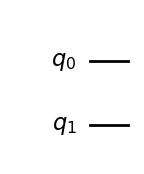

In [7]:
# Oracle for f(x) = 0
def oracle_constant_0():
    """Oracle for f(x) = 0 (constant).

    Implements the quantum oracle transformation: |x⟩|y⟩ → |x⟩|y ⊕ 0⟩ = |x⟩|y⟩
    None of the input bits are flipped, the output will always be 0.

    Returns:
        A 2-qubit circuit implementing the oracle.
    """
    qc = QuantumCircuit(2)

    return qc

display(oracle_constant_0().draw('mpl'))

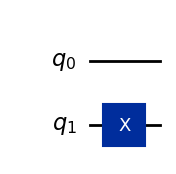

In [8]:
# Oracle for f(x) = 1
def oracle_constant_1():
    """Oracle for f(x) = 1 (constant).

    Implements the quantum oracle transformation: |x⟩|y⟩ → |x⟩|y ⊕ 1⟩
    Flips all input bits, the output will always be 1.

    Returns:
        A 2-qubit circuit implementing the oracle.
    """

    qc = QuantumCircuit(2)
    qc.x(1)

    return qc

display(oracle_constant_1().draw('mpl'))

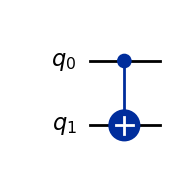

In [9]:
# Oracle for f(x) = x
def oracle_identity():
    """Oracle for f(x) = x (balanced).

    Implements the quantum oracle transformation: |x⟩|y⟩ → |x⟩|y ⊕ x⟩
    Uses a single CNOT gate to flip the second qubit if the first qubit is 1, otherwise remains unchanged.

    Returns:
        A 2-qubit circuit implementing the oracle.
    """

    qc = QuantumCircuit(2)
    qc.cx(0, 1)
    
    return qc

display(oracle_identity().draw('mpl'))

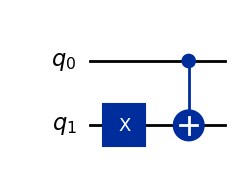

In [10]:
# Oracle for f(x) = ¬x
def oracle_not():
    """Oracle for f(x) = NOT x (balanced).

    Implements the quantum oracle transformation: |x⟩|y⟩ → |x⟩|y ⊕ ¬x⟩
    Flips the input, then uses a CNOT gate to flip the second qubit if the first qubit is 0, otherwise remains unchanged.

    Returns:
        A 2-qubit circuit implementing the oracle.
    """

    qc = QuantumCircuit(2)
    qc.x(1)
    qc.cx(0, 1)

    return qc

display(oracle_not().draw('mpl'))

## Problem 4: Deutsch's Algorithm with Qiskit

## Problem 5: Scaling to the Deutsch-Jozsa Algorithm